# E-commerce Sales Analysis
## 1. Project Overview
This project analyses an e-commerce transaction dataset to identify key revenue drivers, customer concentration, geographic sales distribution, and seasonal demand patterns.

The goal is to demonstrate how data analysis can generate actionable business insights from raw transaction data.

## 2. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
import os

os.makedirs("Data_Analysis_Business/Outputs/Charts", exist_ok=True)

## 3. Load dataset

In [3]:
df = pd.read_csv(
    "Data_Analysis_Business/Datasets/ecommerce_data.csv",
    encoding="latin1"
)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 4. Data cleaning
Here I have removed rows that are a missing customer ID

In [4]:
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


## 5. Product revenue analysis

In [5]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [6]:
df["Profit"] = df["Revenue"] * 0.30

In [7]:
profit_by_product = (
    df.groupby("Description")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_product.head(10)

Description
REGENCY CAKESTAND 3 TIER              39861.120
WHITE HANGING HEART T-LIGHT HOLDER    28147.155
JUMBO BAG RED RETROSPOT               24971.028
PARTY BUNTING                         20306.259
POSTAGE                               20013.072
ASSORTED COLOUR BIRD ORNAMENT         16949.766
RABBIT NIGHT LIGHT                    15341.340
CHILLI LIGHTS                         13781.043
PAPER CHAIN KIT 50'S CHRISTMAS        12450.144
PICNIC BASKET WICKER 60 PIECES        11885.850
Name: Profit, dtype: float64

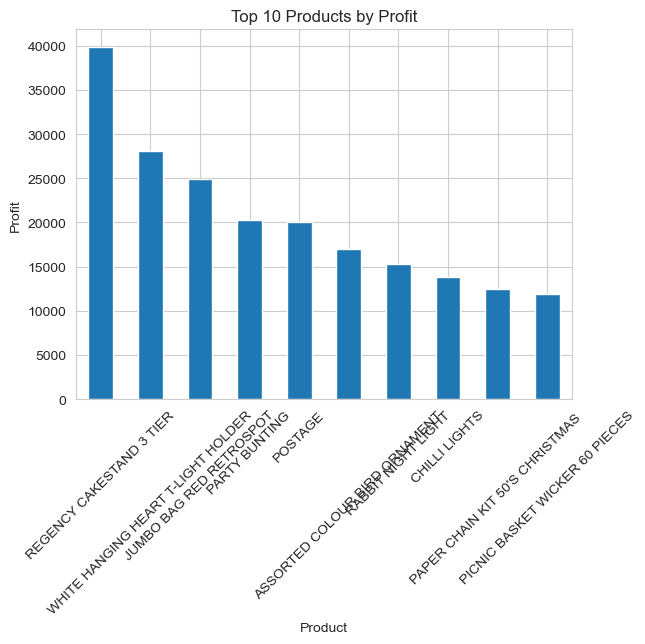

In [8]:
top_products = profit_by_product.head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Profit")
plt.ylabel("Profit")
plt.xlabel("Product")

plt.xticks(rotation=45)

plt.show()

In [9]:
product_sales = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

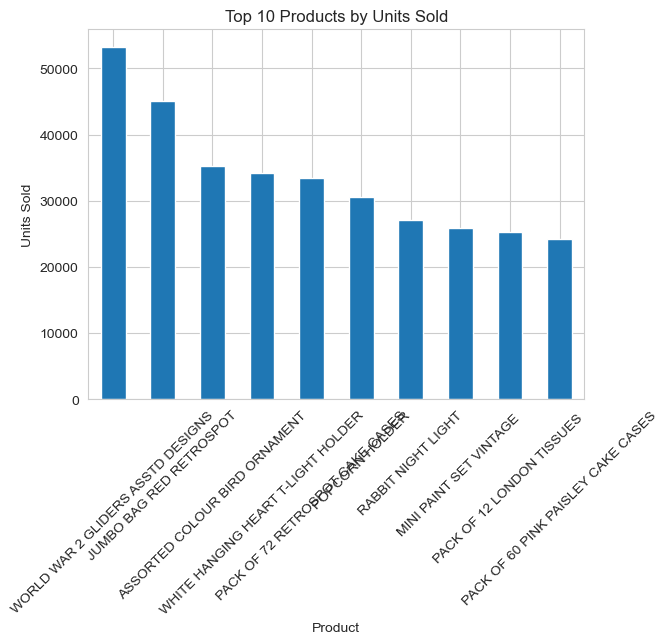

In [10]:
top_products = product_sales.head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Units Sold")
plt.ylabel("Units Sold")
plt.xlabel("Product")

plt.xticks(rotation=45)
plt.show()

## 6. Product Pareto analysis

In [11]:
revenue_by_product = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [12]:
revenue_by_product.head(10)

Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64

In [13]:
pareto_df = revenue_by_product.reset_index()

pareto_df.columns = ["Product", "Revenue"]

In [14]:
pareto_df["Cumulative Revenue"] = pareto_df["Revenue"].cumsum()

In [15]:
pareto_df["Cumulative %"] = (
    pareto_df["Cumulative Revenue"] / pareto_df["Revenue"].sum()
) * 100

In [16]:
pareto_df.head()

,Product,Revenue,Cumulative Revenue,Cumulative %
0,REGENCY CAKESTAND 3 TIER,132870.40,132870.40,1.600835
1,WHITE HANGING HEART T-LIGHT HOLDER,93823.85,226694.25,2.731234
2,JUMBO BAG RED RETROSPOT,83236.76,309931.01,3.734079
3,PARTY BUNTING,67687.53,377618.54,4.549585
4,POSTAGE,66710.24,444328.78,5.353316


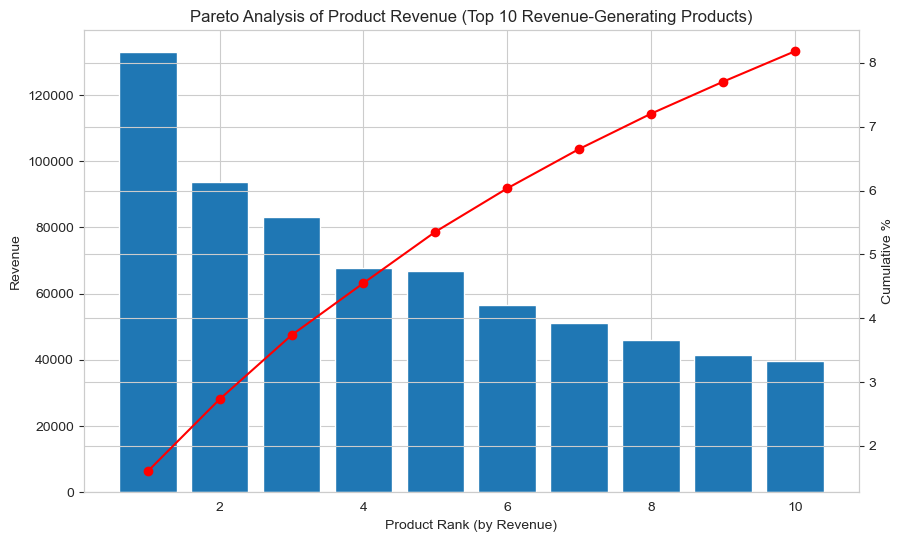

In [32]:
top_n = 10

top_data = pareto_df.head(top_n)

fig, ax = plt.subplots(figsize=(10,6))

# Bars
ax.bar(range(1, top_n+1), top_data["Revenue"])

# Line
ax2 = ax.twinx()
ax2.plot(range(1, top_n+1), top_data["Cumulative %"], color="red", marker="o")

# Labels
ax.set_xlabel("Product Rank (by Revenue)")
ax.set_ylabel("Revenue")
ax2.set_ylabel("Cumulative %")

ax.set_title("Pareto Analysis of Product Revenue (Top 10 Revenue-Generating Products)")

plt.savefig("Data_Analysis_Business/Outputs/Charts/product_pareto.png", dpi=300)
plt.show()

In [18]:
pareto_df[pareto_df["Cumulative %"] <= 80].shape

(808, 4)

## 7. Revenue by country

In [19]:
revenue_by_country = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_country.head(10)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

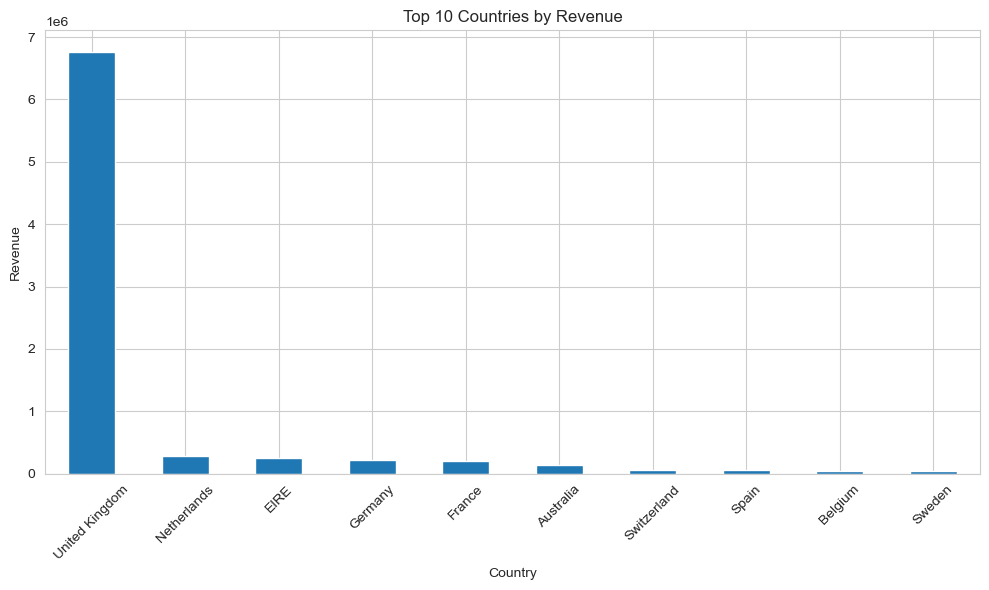

In [33]:
top_countries = revenue_by_country.head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Data_Analysis_Business/Outputs/Charts/country_revenue.png", dpi=300)
plt.show()

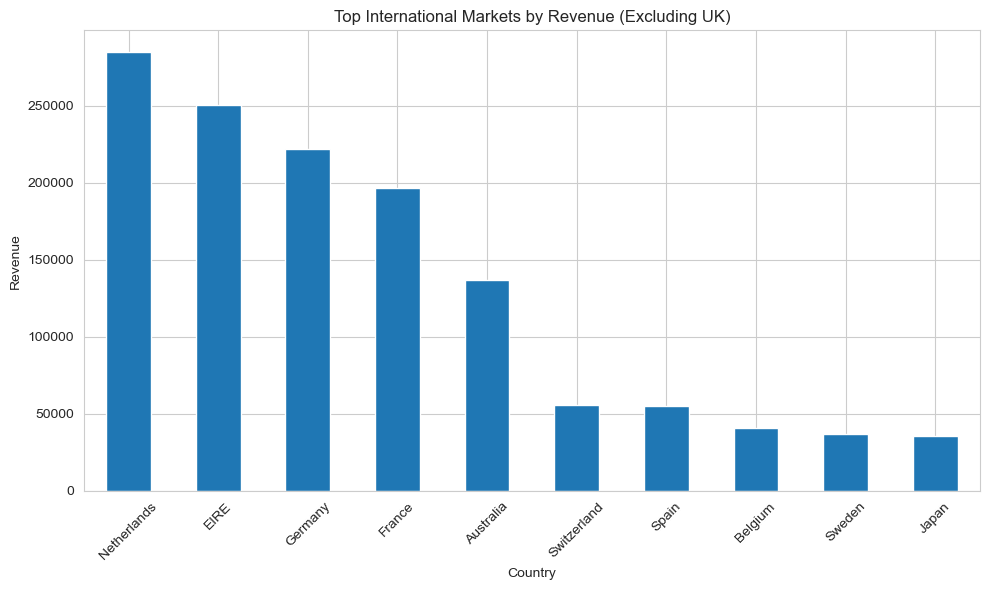

In [34]:
international_revenue = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_international = international_revenue.head(10)

plt.figure(figsize=(10,6))
top_international.plot(kind="bar")

plt.title("Top International Markets by Revenue (Excluding UK)")
plt.ylabel("Revenue")
plt.xlabel("Country")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Data_Analysis_Business/Outputs/Charts/international_revenue.png", dpi=300)
plt.show()

## 8. Monthly revenue trend

In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [23]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [24]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

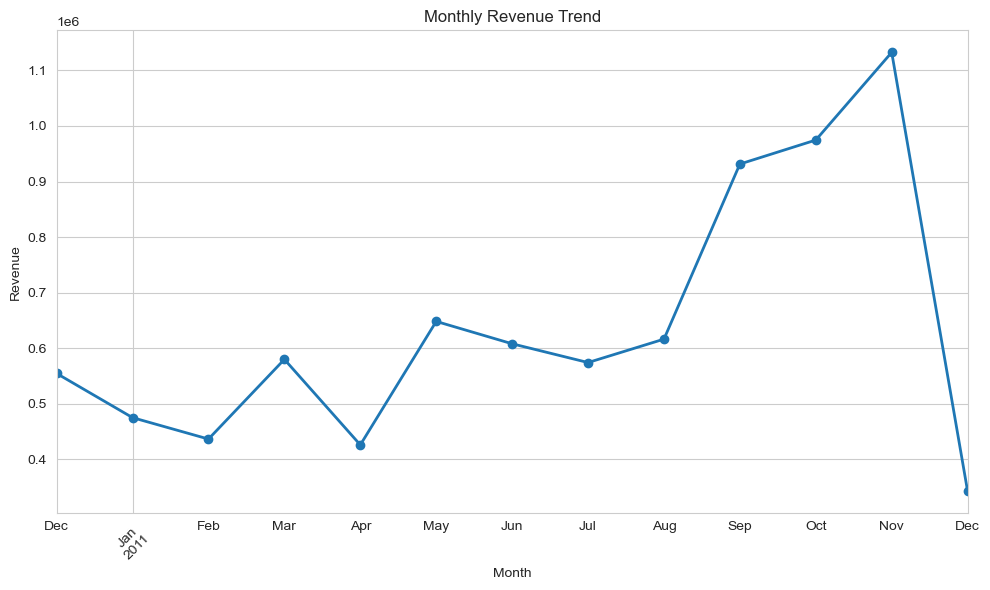

In [35]:
plt.figure(figsize=(10,6))

monthly_revenue.plot(marker="o", linewidth=2)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Data_Analysis_Business/Outputs/Charts/monthly_revenue.png", dpi=300)
plt.show()

## 9. Customer segmentation

In [26]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

In [27]:
customer_revenue.shape

(4372,)

In [28]:
customer_df = customer_revenue.reset_index()
customer_df.columns = ["CustomerID", "Revenue"]

customer_df["Cumulative Revenue"] = customer_df["Revenue"].cumsum()

total_revenue = customer_df["Revenue"].sum()

customer_df["Cumulative %"] = (
    customer_df["Cumulative Revenue"] / total_revenue * 100
)

In [29]:
customer_df[customer_df["Cumulative %"] <= 80].shape

(1170, 4)

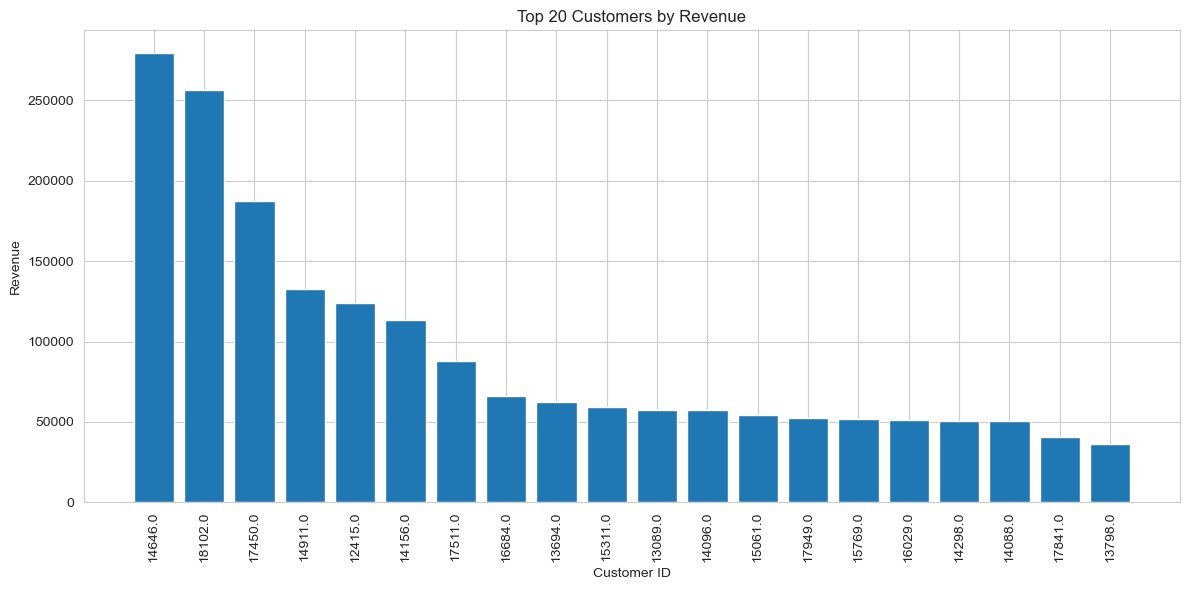

In [30]:
top_customers = customer_df.head(20)

plt.figure(figsize=(12,6))

plt.bar(range(len(top_customers)), top_customers["Revenue"])

plt.xticks(range(len(top_customers)),
           top_customers["CustomerID"],
           rotation=90)

plt.title("Top 20 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

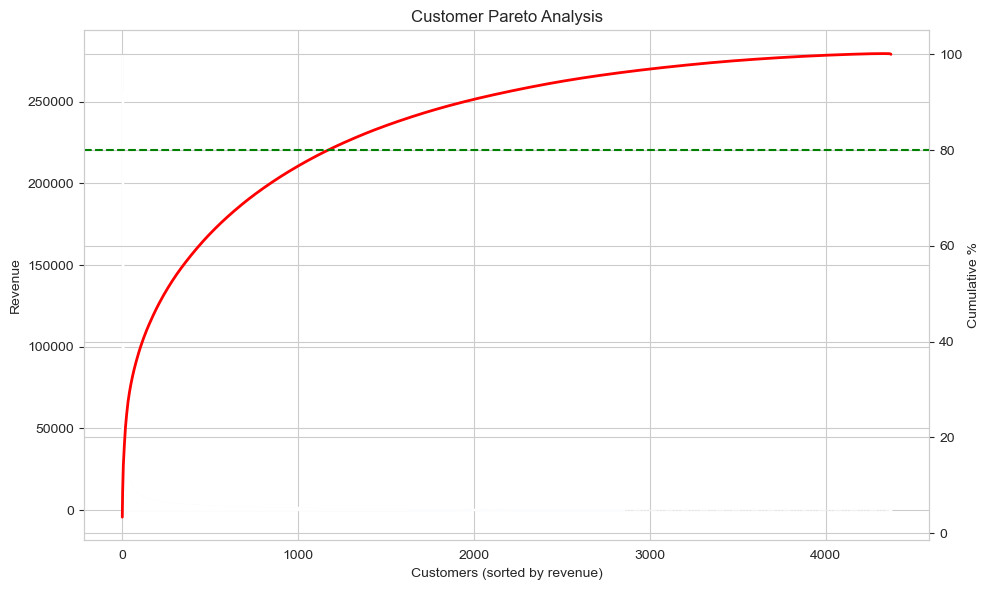

In [36]:
customer_pareto = customer_df.copy()

fig, ax1 = plt.subplots(figsize=(10,6))

# Revenue bars
ax1.bar(range(len(customer_pareto)), customer_pareto["Revenue"])
ax1.set_ylabel("Revenue")
ax1.set_xlabel("Customers (sorted by revenue)")

# Second axis for cumulative %
ax2 = ax1.twinx()

ax2.plot(range(len(customer_pareto)),
         customer_pareto["Cumulative %"],
         color="red",
         linewidth=2)

ax2.axhline(80, color="green", linestyle="--")
ax2.set_ylabel("Cumulative %")

plt.title("Customer Pareto Analysis")

plt.tight_layout()
plt.savefig("Data_Analysis_Business/Outputs/Charts/customer_pareto.png", dpi=300)
plt.show()

## 10. Business Insights

### Customer Concentration
Approximately 27% of customers generate 80% of total revenue. While a small number of high-value customers contribute significant revenue individually, the business benefits from a relatively broad customer base.

### Geographic Distribution
The United Kingdom dominates total revenue, though the Netherlands, Ireland, Germany and France represent the largest international markets.

### Seasonality
Revenue increases throughout the year and peaks sharply in November, indicating strong seasonal demand during the holiday period.

### Product Distribution
A small number of products generate a disproportionately large share of revenue, consistent with Pareto distribution patterns.